In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# 1. Load Data & Preprocess
DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(DATA_URL)

In [3]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Select features and target
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

X = df[features].copy()
y = df[target].copy()

In [5]:
# Simple Imputation
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Fare'] = X['Fare'].fillna(X['Fare'].median())
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])

In [6]:
# Encode Categorical Variables
le_sex = LabelEncoder()
X['Sex'] = le_sex.fit_transform(X['Sex'])

le_embarked = LabelEncoder()
X['Embarked'] = le_embarked.fit_transform(X['Embarked'])

In [7]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# 2. Train Models (Single Model vs. Ensembles)
models = {
    'Decision Tree (Single Model)': DecisionTreeClassifier(random_state=42),
    'Random Forest (Ensemble - Bagging)': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost (Ensemble - Boosting)': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })


In [9]:
# 3. Print Results Comparison
results_df = pd.DataFrame(results)
print("=== MODEL PERFORMANCE COMPARISON ===")
print(results_df.to_string(index=False))

=== MODEL PERFORMANCE COMPARISON ===
                             Model  Accuracy  Precision  Recall  F1-Score
      Decision Tree (Single Model)    0.8324     0.8000  0.7536    0.7761
Random Forest (Ensemble - Bagging)    0.8268     0.8065  0.7246    0.7634
     XGBoost (Ensemble - Boosting)    0.7989     0.7797  0.6667    0.7188


/tmp/ipykernel_2308/2853474168.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='Blues_r')
/tmp/ipykernel_2308/2853474168.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_importances.values, y=xgb_importances.index, palette='Greens_r')


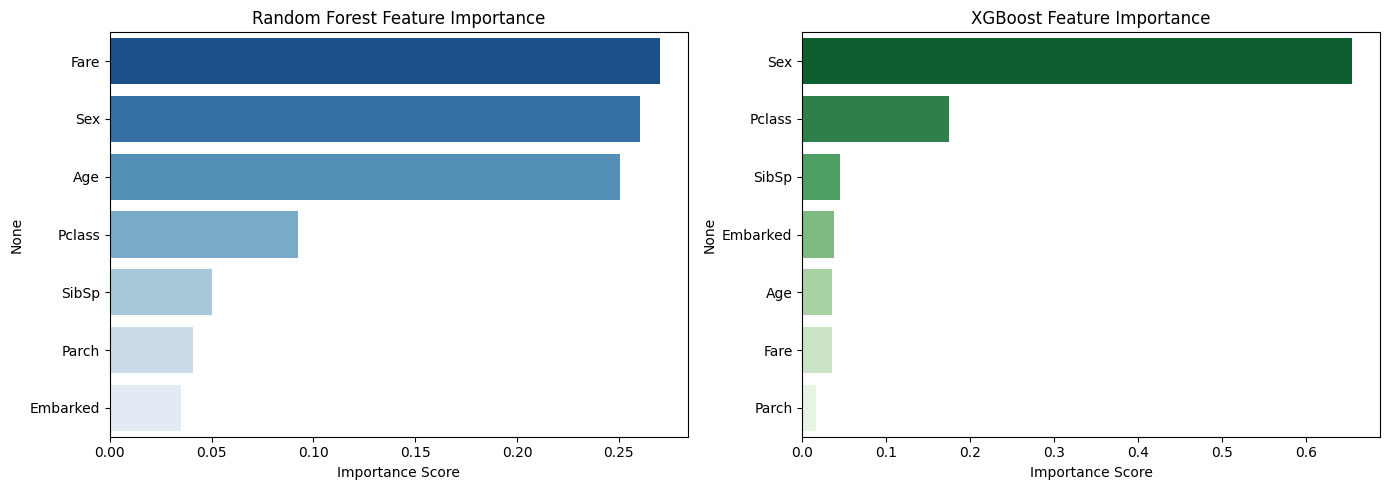

In [12]:
# 4. Plot Feature Importances (Random Forest vs. XGBoost)
rf_model = models['Random Forest (Ensemble - Bagging)']
xgb_model = models['XGBoost (Ensemble - Boosting)']

rf_importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='Blues_r')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')

plt.subplot(1, 2, 2)
sns.barplot(x=xgb_importances.values, y=xgb_importances.index, palette='Greens_r')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()